<a href="https://colab.research.google.com/github/Zouzzou21/TIP-Projet-IRM-Cerveau/blob/main/TUMOR_DETECTION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Import jeux de donnée

#### Import des images d'entrainement et decompression du fichier zip.

In [ ]:
!rm -rf FINAL
!rm -rf FINAL.zip
!wget https://github.com/Zouzzou21/TIP-Projet-IRM-Cerveau/raw/main/FINAL.zip
!unzip FINAL.zip

### Python

#### Import python

In [ ]:
import pathlib
import os
import io
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model
from tensorflow import keras
import tensorflow as tf
import cv2
from google.colab import files
import numpy as np
import pathlib
from os import walk
import pandas as pd
from PIL import Image, ImageEnhance, ImageOps
import sys
import datetime
from tensorflow.keras import layers
import keras

#### Recupération du jeux de données

In [ ]:
data_dir = pathlib.Path('/content/FINAL')
print(data_dir)

print(os.path.abspath(data_dir))

image_count = len(list(data_dir.glob('*/*')))
print(image_count)

/content/FINAL
/content/FINAL
1176


#### Mise en forme des images (size et colorimetrie)

In [ ]:
batch_size = 5
img_width = img_height = 500

train_data = tf.keras.preprocessing.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="training",
  seed=42,
  image_size=(img_height, img_width),
  batch_size=batch_size,
  )

val_data = tf.keras.preprocessing.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="validation",
  seed=42,
  image_size=(img_height, img_width),
  batch_size=batch_size)

class_names = val_data.class_names
print(class_names)

Found 1176 files belonging to 4 classes.
Using 941 files for training.
Found 1176 files belonging to 4 classes.
Using 235 files for validation.
['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']


#### Affichage des differentes photos de tumeurs

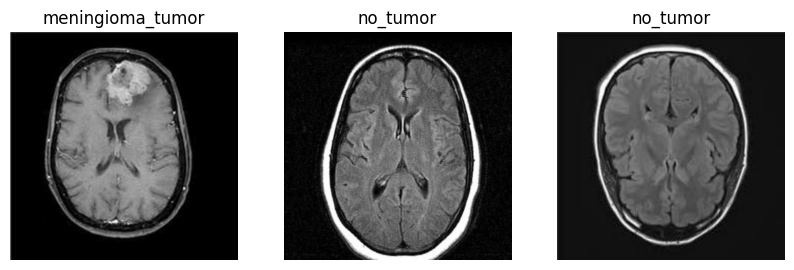

In [ ]:
plt.figure(figsize=(10, 10))
for images, labels in train_data.take(1):
  for i in range(3):
    ax = plt.subplot(1, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

#### Création du réseau de neuronnes

In [ ]:
num_classes = 4

model = tf.keras.Sequential([
    layers.experimental.preprocessing.Rescaling(1./255),
    layers.Conv2D(128, 4, activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 4, activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(32, 4, activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(16, 4, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

logdir = "logs"
tensorboard_callback = keras.callbacks.TensorBoard(log_dir=logdir, histogram_freq=1, write_images=True)
epochs = 10

model.fit(
    train_data,
    validation_data=val_data,
    epochs=epochs,
    callbacks=[tensorboard_callback]
)

Epoch 1/6
189/189 [==============================] - 25s 119ms/step - loss: 1.1825 - accuracy: 0.4867 - val_loss: 0.9030 - val_accuracy: 0.6638
Epoch 2/6
189/189 [==============================] - 23s 120ms/step - loss: 0.8106 - accuracy: 0.6769 - val_loss: 0.9437 - val_accuracy: 0.7021
Epoch 3/6
189/189 [==============================] - 23s 121ms/step - loss: 0.5585 - accuracy: 0.7960 - val_loss: 0.8690 - val_accuracy: 0.7191
Epoch 4/6
189/189 [==============================] - 23s 119ms/step - loss: 0.3429 - accuracy: 0.8820 - val_loss: 1.0878 - val_accuracy: 0.7106
Epoch 5/6
189/189 [==============================] - 22s 117ms/step - loss: 0.2051 - accuracy: 0.9394 - val_loss: 1.5533 - val_accuracy: 0.7277
Epoch 6/6
189/189 [==============================] - 22s 116ms/step - loss: 0.1293 - accuracy: 0.9564 - val_loss: 1.9154 - val_accuracy: 0.7489


#### Affichage du sommaire du model de neuronnes

In [ ]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 rescaling (Rescaling)       (None, 500, 500, 3)       0         
                                                                 
 conv2d (Conv2D)             (None, 497, 497, 128)     6272      
                                                                 
 max_pooling2d (MaxPooling2  (None, 248, 248, 128)     0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 245, 245, 64)      131136    
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 122, 122, 64)      0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 119, 119, 32)      3

#### Import des images de test et decompression du fichier zip.

In [ ]:
!rm -rf TEST
!rm -rf TEST.zip
!wget https://github.com/Zouzzou21/TIP-Projet-IRM-Cerveau/raw/main/TEST.zip
!unzip TEST.zip

#### Test du model avec les images de test

In [ ]:
data_dir_TEST = pathlib.Path('/content/TEST')
print(data_dir_TEST)
print(os.path.abspath(data_dir_TEST))
image_count_TEST = len(list(data_dir_TEST.glob('*/*')))
print(image_count_TEST)

##REPERTOIRE DES CLASSES
no_tumor_dir = os.path.join('/content/TEST/no_tumor')
glioma_tumor_dir = os.path.join('/content/TEST/glioma_tumor/')
meningioma_tumor_dir = os.path.join('/content/TEST/meningioma_tumor')
pituitary_tumor_dir = os.path.join('/content/TEST/pituitary_tumor')

##OBTENIR LE NOMBRE D'IRM EN FONCTION DE CHAQUE CLASSE
nbrPasTumeur = len(os.listdir(no_tumor_dir))
nbrGliomaTumeur = len(os.listdir(glioma_tumor_dir))
nbrMeningiomaTumeur = len(os.listdir(meningioma_tumor_dir))
nbrPituitaryTumeur = len(os.listdir(pituitary_tumor_dir))

##MISE EN PLACE DES COMPTEURS POUR DETERMINER LES DETECTIONS PAR RAPPORT AU RESEAU
CompteurGlioma = 0
CompteurMeningioma = 0
CompteurPasTumeur = 0
CompteurPituitary = 0

/content/TEST
/content/TEST
529


In [ ]:
##POUR CHAQUE IRM, ON L'ENVOIE DANS LE RESEAU DE NEURONE POUR DETERMINER SA CLASSE
CompteurLogique = nbrErreur = interaction = 0
liste_Erreur_10ech = []

for dossier_parent, sous_repertoires, fichiers in os.walk(data_dir_TEST):
    for nom_fichier in fichiers:
        CompteurLogique = CompteurLogique + 1
        interaction = interaction + 1
        chemin_image = os.path.join(dossier_parent, nom_fichier)

        if nom_fichier.lower().endswith(('.png', '.jpg', '.jpeg')):

          image_to_predict_RGB = Image.open(chemin_image).convert('RGB')
          image_to_predict_GRAY = cv2.cvtColor(np.array(image_to_predict_RGB), cv2.COLOR_RGB2GRAY)

          image_to_predict = np.array(image_to_predict_RGB)
          image_to_predict = cv2.resize(image_to_predict, (img_height, img_width))
          image_to_predict = np.expand_dims(image_to_predict, axis=0)
          ClassProbability = model.predict(image_to_predict)

          ##DETERMINER LA PROBABILITE LA PLUS FORTE
          numpy_array = np.array(ClassProbability)

          ##OBTENIR L'INDEX OU LA PROBABILITE EST LA PLUS FORTE
          val = np.argmax(numpy_array)

        ##EN FONCTION DE LA VALEUR MAX DE PROBABILITE DANS CLASSPROBABILITY ON ESTIME SA CLASSE (FIABILITE DIFFERENTE DE 100%, C'EST POUR CELA QU'ON ESTIME)
        if val == 0:
          CompteurGlioma = CompteurGlioma + 1
        elif val == 1 :
          CompteurMeningioma = CompteurMeningioma + 1
        elif val == 2  :
          CompteurPasTumeur = CompteurPasTumeur + 1
        elif val == 3 :
          CompteurPituitary = CompteurPituitary + 1

        if dossier_parent == "/content/TEST/glioma_tumor":
          if CompteurLogique == len(os.listdir(glioma_tumor_dir)):
            CompteurLogique = CompteurGlioma = CompteurMeningioma = CompteurPasTumeur = CompteurPituitary = 0
            break
          elif CompteurLogique != CompteurGlioma :
            CompteurGlioma = CompteurGlioma + 1
            nbrErreur = nbrErreur + 1

        elif dossier_parent == "/content/TEST/no_tumor":
          if CompteurLogique == len(os.listdir(no_tumor_dir)):
            CompteurLogique = CompteurGlioma = CompteurMeningioma = CompteurPasTumeur = CompteurPituitary = 0
            break
          elif CompteurLogique != CompteurPasTumeur :
            CompteurPasTumeur = CompteurPasTumeur + 1
            nbrErreur = nbrErreur + 1

        elif dossier_parent == "/content/TEST/pituitary_tumor":
          if CompteurLogique == len(os.listdir(pituitary_tumor_dir)):
            CompteurLogique = CompteurGlioma = CompteurMeningioma = CompteurPasTumeur = CompteurPituitary = 0
            break
          elif CompteurLogique != CompteurPituitary :
            CompteurPituitary = CompteurPituitary + 1
            nbrErreur = nbrErreur + 1

        elif dossier_parent == "/content/TEST/meningioma_tumor":
          if CompteurLogique == len(os.listdir(meningioma_tumor_dir)):
            CompteurLogique = CompteurGlioma = CompteurMeningioma = CompteurPasTumeur = CompteurPituitary = 0
            break
          elif CompteurLogique != CompteurMeningioma :
            CompteurMeningioma = CompteurMeningioma + 1
            nbrErreur = nbrErreur + 1

        if interaction % 10 == 0:
          liste_Erreur_10ech.append(nbrErreur)
          nbrErreur = 0
    print(liste_Erreur_10ech)




[]
1/1 [==============================] - 0s 17ms/step
[2, 4, 4, 6, 1, 2, 4, 2, 2, 2, 5, 3, 3, 3]
1/1 [==============================] - 0s 18ms/step
[2, 4, 4, 6, 1, 2, 4, 2, 2, 2, 5, 3, 3, 3, 4, 4, 5, 4, 6, 2, 3, 2, 7, 2, 7]
1/1 [==============================] - 0s 17ms/step
[2, 4, 4, 6, 1, 2, 4, 2, 2, 2, 5, 3, 3, 3, 4, 4, 5, 4, 6, 2, 3, 2, 7, 2, 7, 5, 1, 1, 1, 1, 2, 2, 2, 2, 0, 1, 1, 2]
1/1 [==============================] - 0s 27ms/step
[2, 4, 4, 6, 1, 2, 4, 2, 2, 2, 5, 3, 3, 3, 4, 4, 5, 4, 6, 2, 3, 2, 7, 2, 7, 5, 1, 1, 1, 1, 2, 2, 2, 2, 0, 1, 1, 2, 4, 3, 6, 7, 4, 6, 4, 5, 5, 5, 7, 2, 3, 3]


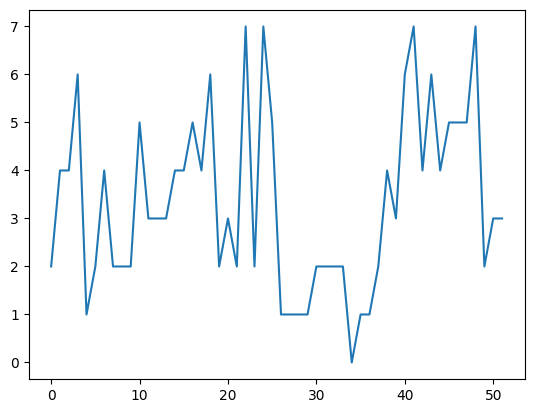

Le taux d'erreur est de : 32.89224952741021
Le taux de réussite est de : 67.1077504725898


In [ ]:
#SCHEMA DES ERREURS
plt.plot(liste_Erreur_10ech)
plt.show()
nbrErreurTotal = 0

nbrTotalImages = nbrGliomaTumeur + nbrMeningiomaTumeur + nbrPasTumeur + nbrPituitaryTumeur
for e in liste_Erreur_10ech:
  nbrErreurTotal = nbrErreurTotal + int(e)
ratio = nbrErreurTotal / nbrTotalImages
pourcentageErreur = ratio * 100
pourcentageReussite = 100 - pourcentageErreur
print("Le taux d'erreur est de : " + str(pourcentageErreur) + "\n"
      "Le taux de réussite est de : " + str(pourcentageReussite)
     )


##AFFICHAGE DES RESULTATS
#print("Glioma = " + str(CompteurGlioma) + "\n"
#      "Meningioma = " + str(CompteurMeningioma) + "\n"
#      "Pas de tumeur = " + str(CompteurPasTumeur) + "\n"
#      "Pituitary = " + str(CompteurPituitary) + "\n"
#      )

##DIFFERENCE OBTENUE
#diffPasTumeur = nbrPasTumeur - CompteurPasTumeur
#diffMeningiomaTumeur = nbrMeningiomaTumeur - CompteurMeningioma
#diffGliomaTumeur = nbrGliomaTumeur - CompteurGlioma
#diffPituitaryTumeur = nbrPituitaryTumeur - CompteurPituitary

##AFFICHAGE DES ERREURS
#print(str(diffGliomaTumeur))
#print(str(diffMeningiomaTumeur))
#print(str(diffPasTumeur))
#print(str(diffPituitaryTumeur))